In [64]:
import numpy as np # for numerical operations
import pandas as pd # data manipulation and analysis
import matplotlib.pyplot as plt # visualization 
import seaborn as sns # advanced statistical visualizations

from sklearn.preprocessing import OneHotEncoder # transform categorical features into dummy variables; 
from sklearn.preprocessing import MinMaxScaler # rescale features to a specific range

from sklearn.linear_model import LinearRegression # for building the linear regression model
from sklearn.model_selection import train_test_split # for splitting the data into train-test 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # metrics
from sklearn.model_selection import cross_val_score # validation
from sklearn.feature_selection import SelectKBest, f_regression # selecting features according to the k highest scores

from scipy import stats # use stats.mode for central tendency

# BSc Computer Science: CM3005 - Data Science

## Q1. Domain-specific area and objectives of the project

This dataset represents the academic performance of about 3,000 students. The dataset includes variables related to study habits, attendance, sleep patterns, stress levels, social media usage, motivation, productivity, and engagement behaviors [1]. Indeed, the quality of academic performance is influenced by various physical and psychological factors that must be taken into consideration to achieve better academic results.

In practice, predicting students' performance is a challenging task. Generally, educational institutions measure students' intellectual ability through interviews, which may include oral tests, written assignments, group work, or examinations [2]. However, according to the Education Data organization, the increasing rate of college dropouts due to academic incompetence or other factors can be traced to misinformation provided by institutional authorities when handling results to students [3].

Human behavior can be more complex and depends on conditions and accidents that cannot be fully analyzed. Despite these challenges, machine learning can be a useful tool to predict who is likely to fail or pass the examination. For instance, linear regression is a technique that establishes a relationship between x and y variables along with their coefficients. Linear regression has been applied in different science disciplines to determine the extent to which there is a linear relationship between a dependent variable and one or more independent variables [2].

This data science project is designed to analyze factors affecting student academic results, identify behavioral patterns associated with high academic performance, and formulate a set of rules for academic achievement. Predictions received from the model serve as a counseling tool for students to improve their work rate or maintain their rate to achieve higher performance.

In [65]:
# Constant variables
TEST_SIZE = 0.2
RANDOM_STATE = 42

FIG_WIDTH = 8
FIG_HEIGHT = 5

NUM_BINS = 20

TOP_FEATURES = 20

In [66]:
# Try-except for reading the dataset in csv-format
try:
    df = pd.read_csv('/kaggle/input/datasets/aiexplorer77/academic-performance-prediction/student_performance_dataset.csv')
    print("Success!")
except Exception as e:
    print(f"Error: {e}")

Success!


In [67]:
# Display dataset dimensions
df.shape

(3000, 32)

In [68]:
# Display the first five observations
df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [69]:
print(f"Amount of columns: {len(df.columns)}\nColumns: {df.columns.tolist()}")

Amount of columns: 32
Columns: ['student_id', 'age', 'gender', 'city_type', 'study_hours_per_day', 'deep_work_sessions', 'assignment_completion_rate', 'attendance_percentage', 'social_media_hours', 'doomscrolling_before_sleep', 'notification_distractions', 'ai_tool_usage_hours', 'gaming_hours', 'stress_level', 'motivation_level', 'focus_score', 'procrastination_index', 'mental_state', 'sleep_hours', 'caffeine_intake', 'physical_activity_hours', 'internet_quality', 'family_support', 'financial_stress', 'learning_style', 'career_goal', 'productivity_after_midnight', 'revision_efficiency', 'burnout_risk', 'consistency_score', 'final_exam_score', 'performance_category']


In [70]:
# Display data types
df.dtypes

student_id                       int64
age                              int64
gender                          object
city_type                       object
study_hours_per_day            float64
deep_work_sessions               int64
assignment_completion_rate       int64
attendance_percentage            int64
social_media_hours             float64
doomscrolling_before_sleep       int64
notification_distractions        int64
ai_tool_usage_hours            float64
gaming_hours                   float64
stress_level                     int64
motivation_level                 int64
focus_score                    float64
procrastination_index            int64
mental_state                    object
sleep_hours                    float64
caffeine_intake                  int64
physical_activity_hours        float64
internet_quality                 int64
family_support                   int64
financial_stress                 int64
learning_style                  object
career_goal              

In [71]:
# Count missing values for each column
missing_values_per_column = df.isna().sum()
print("Columns NaN:")
print(missing_values_per_column)

Columns NaN:
student_id                      0
age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours             60
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
burnout_risk                    0
c

In [72]:
total_percentage_nan = df.isna().sum().sum() / df.size * 100
print(f"Total percentage of NaN: {total_percentage_nan}")

Total percentage of NaN: 0.1875


In [73]:
num_features = df.select_dtypes(include=['int64','float64']).shape[1]
categorical_features = df.select_dtypes(include=['object']).shape[1]
print(f"Numerical features: {num_features}; categorical features: {categorical_features}")

Numerical features: 26; categorical features: 6


In [74]:
# Count duplicated rows
duplicates = df.duplicated().sum()
print(f"Duplicates: {duplicates}")

Duplicates: 0


In [75]:
# Summary statistics for numerical variables
df.describe()

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,19.030333,3.988767,3.511667,69.926333,74.558000,2.949422,0.493000,61.961667,1.538933,...,3.500333,1.054167,5.552000,5.467667,5.556667,5.546333,5.446000,5.535000,5.512333,54.795667
std,866.169729,2.553217,1.503377,2.297743,17.562794,14.473048,1.510306,0.500034,33.125156,0.925619,...,2.274436,0.725919,2.906564,2.856047,2.865809,2.864132,2.890421,2.837157,2.860287,18.691309
min,0.000000,15.000000,0.500000,0.000000,40.000000,50.000000,0.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,749.750000,17.000000,2.900000,1.000000,55.000000,62.000000,1.900000,0.000000,32.000000,0.900000,...,2.000000,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,42.000000
50%,1499.500000,19.000000,4.000000,4.000000,70.000000,74.000000,2.900000,0.000000,62.000000,1.500000,...,3.000000,1.000000,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000,55.000000
75%,2249.250000,21.000000,5.000000,6.000000,85.000000,87.000000,4.000000,1.000000,91.000000,2.100000,...,5.000000,1.600000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,67.000000
max,2999.000000,23.000000,8.800000,7.000000,100.000000,100.000000,8.900000,1.000000,119.000000,5.000000,...,7.000000,3.900000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


In [76]:
print(f"Final exam score range: {df['final_exam_score'].value_counts()}")
df['final_exam_score'].describe()

Final exam score range: final_exam_score
62    70
59    69
60    68
47    67
56    67
      ..
4      2
8      2
0      2
10     2
2      1
Name: count, Length: 98, dtype: int64


count    3000.000000
mean       54.795667
std        18.691309
min         0.000000
25%        42.000000
50%        55.000000
75%        67.000000
max       100.000000
Name: final_exam_score, dtype: float64

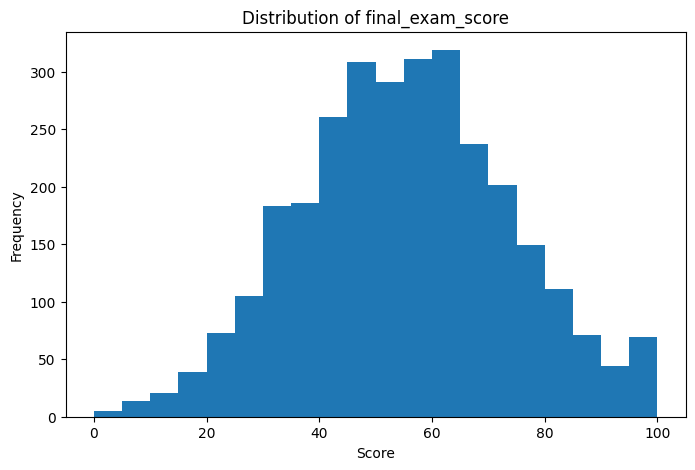

In [77]:
# Plot the distribution of final exam scores
plt.figure(figsize=(FIG_WIDTH,FIG_HEIGHT))

plt.hist(df['final_exam_score'], bins=NUM_BINS)
plt.title('Distribution of final_exam_score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

**The histogram of the final_exam_score variable demonstrates a distribution that appears approximately bell-shaped and resembles a normal (Gaussian) distribution. A normal distribution is a continuous probability distribution that is symmetric around its mean, forming a bell-shaped curve [6]. The observed distribution suggests that most students achieve scores close to the average value, while extremely low and extremely high scores occur less frequently.**

In [78]:
print(f"Performance category values: {df['performance_category'].value_counts()}")

Performance category values: performance_category
Medium    1360
Low       1196
High       444
Name: count, dtype: int64


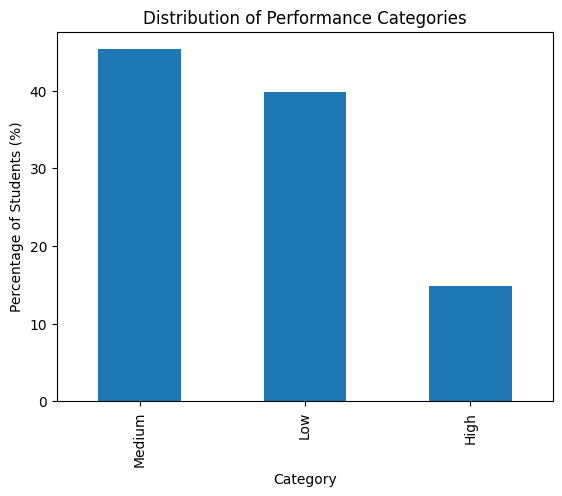

In [79]:
performance_values = df['performance_category'].value_counts()
performance_percetage = (performance_values / len(df) * 100)

performance_percetage.plot(kind='bar')

plt.title('Distribution of Performance Categories')
plt.xlabel('Category')
plt.ylabel('Percentage of Students (%)')
plt.show()

**This bar chart illustrates the distribution of students across the three academic performance categories: Low, Medium, and High. As shown in the figure, the majority of students belong to the Medium performance category, while the High category contains noticeably fewer observations.**

**The distribution indicates a moderate class imbalance, which should be considered during later stages of modelling and evaluation.**

## Q2. Dataset description

The Student Academic Performance dataset was collected and published on Kaggle by a data science enthusiast. It represents simulated real-world students' educational performance and behaviour patterns. The dataset is publicly available through the Kaggle platform [1].

The dataset contains records for 3,000 students and includes 32 features describing various aspects of academic performance and lifestyle. The variables cover demographic information (e.g., age, gender, city type), study habits (study hours per day, deep work sessions, revision efficiency), behavioural indicators (social media usage, gaming hours, procrastination index), and well-being factors (sleep hours, stress level, mental state, physical activity). The dataset also includes outcome-related variables represented by students' final exam scores and performance categories.

Most variables are stored in numerical format (int64 and float64), while several categorical attributes are represented as object (string) values. The number of numerical and categorical features is 26 and 6, respectively.

Data quality inspection showed a very low proportion of missing values. The overall percentage of missing data is approximately 0.19% of the dataset. Missing values appear only in three variables: `social_media_hours`, `focus_score`, and `sleep_hours`, with 60 missing observations in each column. No duplicate observations were found.

The dataset contains two target variables: `final_exam_score` and `performance_category`. The dataset can be used for either regression (predicting final exam scores) or classification (predicting student performance categories). The regression target ranges from 0 to 100, while the classification target has three outcomes: Low, Medium, and High. However, the classification target is moderately imbalanced, with the High category occurring less frequently than the Low and Medium categories.

This dataset is well-suited for linear regression because the primary target variable, `final_exam_score`, is continuous and many features, such as study hours and attendance, are expected to have a roughly linear relationship with academic performance. The model will take the student data as input and predict their final exam score. Additionally, the dataset allows the use of the categorical target as an auxiliary helper for further analysis.

Since the dataset is synthetically generated rather than collected from real educational institutions, conclusions should be interpreted with caution.

## Q3. Data preparation (acquisition/cleaning/sanitisation/normalisation)

#### 3.1. Data acquisition
The source of the dataset is Kaggle. The dataset is provided in CSV (Comma-Separated Values) format and was loaded into a Pandas DataFrame for preprocessing, analysis, and model development.

#### 3.2. Data inspection

**Dataset description:**
* Total records: 3,000
* Total features: 32
* Numerical features: 26
* Categorical features: 6
* Missing data: ~0.19%
* Target variables: `final_exam_score`, `performance_category` 

#### 3.3. Data cleaning

To preserve the original dataset, a copy of the DataFrame was created before applying any preprocessing operations. This ensures that the source data remains unchanged and allows the preprocessing steps to be reproduced or modified if necessary.



In [80]:
# Create a copy of the original dataset
df_copy = df.copy()

Data quality is an important stage of any data science project. Before building a machine learning model, the dataset should be inspected for missing values, inconsistencies, and potential errors. In Pandas, missing values are represented as NaN.

The inspection showed that the dataset contained a very small amount of missing data (0.19% of all observations), affecting only three variables: `social_media_hours`, `focus_score`, and `sleep_hours`.

Since the proportion of missing values was low, median imputation was selected as the preprocessing method. The median was chosen instead of the mean because it is less sensitive to extreme values and helps preserve the central tendency of the distribution.

In [81]:
print(f"Before fill the gaps: {df_copy.isna().sum().sum()}")

df_copy['social_media_hours'] = df_copy['social_media_hours'].fillna(df_copy['social_media_hours'].median())
print(f"Social media average hours: {df_copy['social_media_hours'].median()}")

df_copy['focus_score'] = df_copy['focus_score'].fillna(df_copy['focus_score'].median())
print(f"Focus average score: {df_copy['focus_score'].median()}")

df_copy['sleep_hours'] = df_copy['sleep_hours'].fillna(df_copy['sleep_hours'].median())
print(f"Average sleep hours: {df_copy['sleep_hours'].median()}")

print(f"After fill the gaps: {df_copy.isna().sum().sum()}")

Before fill the gaps: 180
Social media average hours: 2.9
Focus average score: 6.0
Average sleep hours: 6.5
After fill the gaps: 0


The missing values were replaced using the following median values:
* Social media average hours: 2.9
* Focus average score: 6.0
* Average sleep hours: 6.5

#### 3.4. Data sanitisation

Data should be complete, consistent, and meaningful before model development. During the sanitisation stage, the identifying column `student_id` was removed from the dataset because it serves only as a unique identifier and does not contain meaningful predictive information.

Keeping identifier variables in machine learning models may negatively affect model performance. Such variables can introduce noise into the learning process, increase the risk of overfitting, and in some cases lead to data leakage if identifiers indirectly encode information unavailable in a real production environment.

In [82]:
print(f"Dataset shape before: {df_copy.shape}")

df_copy = df_copy.drop(columns=['student_id'])

print(f"Dataset shape after: {df_copy.shape}")

Dataset shape before: (3000, 32)
Dataset shape after: (3000, 31)


#### 3.5. Data transformation

Linear regression is a supervised algorithm that learns to model a dependent variable, `y`, as a function of some independent variables (features), `x`, by finding a line that best "fits" th data [4]. In general, the equation for linear regression is:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p + \epsilon
$$

As the mathematics behind linear regression is linear algebra, categorical variables are generally converted to dummy variables [5].

In [83]:
categorical_columns = df_copy.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns: ")
print(*categorical_columns, sep="; ")

Categorical columns: 
gender; city_type; mental_state; learning_style; career_goal; performance_category


In [84]:
# One-Hot Encoding applying
categorical_columns = [
    col
    for col in categorical_columns
    if col != 'performance_category'
]

encoder = OneHotEncoder(
    sparse_output=False,
    drop='first'
)

encoded_data = encoder.fit_transform(
    df_copy[categorical_columns]
)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=df_copy.index
)

final_df = pd.concat(
    [
        df_copy.drop(columns=categorical_columns),
        encoded_df
    ],
    axis=1
)

One-Hot Encoding was applied to the remaining categorical variables, converting each category into binary indicator columns. As a result, the categorical attributes became suitable for use in linear regression modelling. 

After transformation, the number of features increased from 31 to 39, while the number of observations remained unchanged at 3,000 records. The drop='first' parameter was applied to avoid redundant variables and reduce multicollinearity between encoded features [5].

In [85]:
print("\nOne-Hot Encoded Data:")
final_df.shape


One-Hot Encoded Data:


(3000, 39)

#### 3.6. Data normalisation

Data preprocessing is one of the most important steps in any machine learning pipeline. Raw data often comes with different scales, units, and distributions, which can lead to poor model performance. To achieve the goal of this project and create a reliable model, it is important to note that linear regression is particularly sensitive to the scale of input features. To handle this, feature scaling is applied [7].

There are two of the most used scaling techniques - MinMaxScaler and StandardScaler. For example, The MinMaxScaler rescales features to a fixed range, usually [0, 1]. In general, its formula is:

$$
x_i = \frac{x_i - x_{\min}}{x_{\max} - x_{\min}}
$$

This data science project is inclined to use MinMaxScaler, because the upper and lower boundaries of each attribute are well known from domain knowledge. Additionally, MinMaxScaler preserves the original distribution shape of the data, which is beneficial for interpretability.

In [86]:
# initialize target columns
target_cols = ['final_exam_score', 'performance_category']

numeric_cols = final_df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if col not in target_cols]

scaler = MinMaxScaler()

print("Before normalization:")
final_df.head(3)

Before normalization:


,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,...,mental_state_Burnout,mental_state_Distracted,mental_state_Focused,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research
0,21,3.2,7,100,70,3.8,0,107,0.6,1.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,19,3.9,2,46,70,2.6,1,93,1.5,1.1,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,16,4.3,7,54,57,4.3,1,82,0.5,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [87]:
final_df[numeric_cols] = scaler.fit_transform(final_df[numeric_cols])

print("After normalization:")
final_df.head(3)

After normalization:


,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,...,mental_state_Burnout,mental_state_Distracted,mental_state_Focused,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research
0,0.750,0.325301,1.000000,1.000000,0.40,0.426966,0.0,0.894737,0.12,0.253521,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.500,0.409639,0.285714,0.100000,0.40,0.292135,1.0,0.771930,0.30,0.154930,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.125,0.457831,1.000000,0.233333,0.14,0.483146,1.0,0.675439,0.10,0.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


The following output verifies the effect of the normalization process.

Indeed, the minimum value is 0.0 and the maximum is 1.0, which corresponds to the range [0, 1]. This confirms that the MinMaxScaler has been applied correctly, as all features are now scaled to the expected range.

In [88]:
final_df['attendance_percentage'].describe()

count    3000.000000
mean        0.491160
std         0.289461
min         0.000000
25%         0.240000
50%         0.480000
75%         0.740000
max         1.000000
Name: attendance_percentage, dtype: float64

## Q4-Q5. Statistical analysis and visualisation

Statistical summary of the data:
- Measures of central tendency
- Measures of spread
- Type of distribution

#### 4.1. Measures of central tendency

Measures of central tendency are statistical indicators that describe the central or typical value of a dataset. They provide a concise summary of the data and help identify its general pattern or behaviour. The three most commonly used measures of central tendency are the mean, median, and mode [8].

The dataset contains 26 numerical features. Calculating and discussing measures of central tendency for every variable would be unnecessarily extensive and would provide limited additional insight. Therefore, a subset of representative features was selected for further analysis:

- `final_exam_score` - the primary target variable used to evaluate academic achievement and observe the distribution of outcomes;
- `social_media_hours` - a behavioural variable selected due to its commonly discussed relationship with student productivity and academic performance;
- `deep_work_sessions` - a measure of focused study activity;
- `study_hours_per_day` - a fundamental study-related variable representing daily learning effort;
- `sleep_hours` - a well-being factor that may affect learning outcomes and concentration;
- `physical_activity_hours` - a physical activity indicator included to explore potential relationships between health habits and academic achievement.

Before starting the analysis, it is important to revise the definitions of each measure:

- Mean is defined as the sum of all observations divided by the total number of observations.  
Example: [2, 4, 6, 8, 10] → mean = (2 + 4 + 6 + 8 + 10) / 5 = 30 / 5 = 6.

- Median is the middle value in a sorted (ordered) dataset.  
Example: [2, 4, 6, 8, 10] → median = 6.

- Mode is the value that occurs most frequently in a dataset.  
Example: [2, 4, 4, 6, 8, 10] → mode = 4.

In [89]:
# Function for central tendency measurements
def central_tendency_graph(df, x):
    x_mean = np.mean(df[x])
    x_median = np.median(df[x])
    x_mode = stats.mode(df[x]).mode.item()

    plt.figure(figsize=(FIG_WIDTH,FIG_HEIGHT))
    plt.hist(df[x], bins=NUM_BINS, alpha=0.5)
    plt.axvline(x_mean, color='g', linestyle='-', label=f"Mean: {x_mean:.2f}")
    plt.axvline(x_median, color='r', linestyle='-', label=f"Median: {x_median:.2f}")
    plt.axvline(x_mode, color='y', linestyle='-', label=f"Mode: {x_mode}")

    plt.title(f"Central tendency of {x}")
    plt.xlabel(x)
    plt.ylabel('Frequency')
    
    plt.legend()
    plt.show()

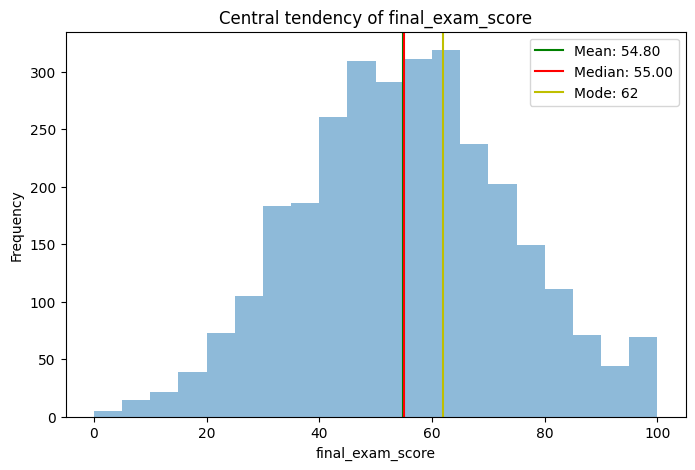

In [90]:
# Select columns suggested for analysis
selected_columns = ['final_exam_score', 'social_media_hours', 'deep_work_sessions', 'study_hours_per_day', 'sleep_hours', 'physical_activity_hours']

# Target feature
central_tendency_graph(final_df, selected_columns[0])

**The histogram represents three measurements of the target feature, `final_exam_score`. The mean and median scores are almost equal, which indicates that the distribution is roughly symmetrical. The mean score of 54.80 indicates that a typical student scores about 55 points out of 100. The median of 55.00 confirms that 50% of students scored less than 55 points, and 50% scored more than 55 points. The mode is 62, which is slightly higher than the mean and median, suggesting a minor peak at that score value. Overall, the distribution appears approximately symmetric and does not show strong skewness. This makes the target variable suitable for further regression analysis.**

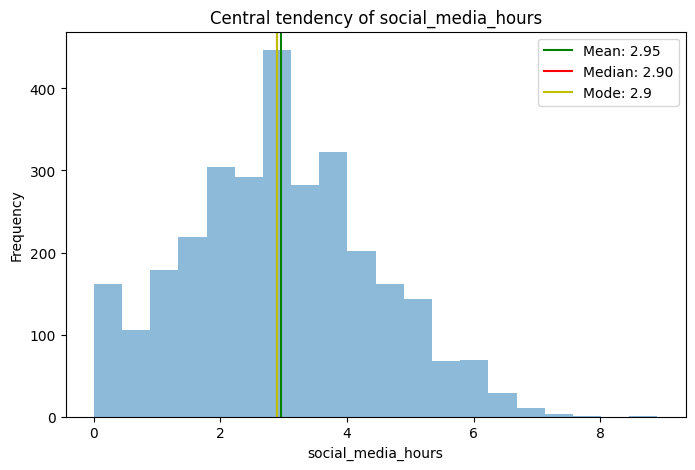

In [91]:
# Hours spent in social media
central_tendency_graph(df_copy, selected_columns[1])

**The chart of `social_media_hours` illustrates the three measures of central tendency. To preserve interpretability, the analysis was performed using the `df_copy` dataset instead of `final_df`, because `social_media_hours` was later transformed into the range from 0 to 1 during Min–Max normalisation. Using the original values allows the results to remain interpretable in terms of actual hours spent on social media.**

**The mean value (2.95) is slightly higher than the median (2.90), indicating a small positive skew in the distribution. The mode (2.90) coincides with the median, suggesting that this is the most frequently observed value. Since all three measures are relatively close, the distribution appears reasonably symmetric without strong evidence of extreme outliers. Overall, most students in the dataset spend approximately 3 hours per day on social media.**

In [92]:
print("Summary:")

summary = pd.DataFrame({
    'Mean': [df_copy[col].mean() for col in selected_columns],
    'Median': [df_copy[col].median() for col in selected_columns],
    'Mode': [stats.mode(df_copy[col]).mode.item() for col in selected_columns]
},
index=selected_columns)

summary.round(2)

Summary:


,Mean,Median,Mode
final_exam_score,54.80,55.0,62.0
social_media_hours,2.95,2.9,2.9
deep_work_sessions,3.51,4.0,4.0
study_hours_per_day,3.99,4.0,4.4
sleep_hours,6.51,6.5,6.5
physical_activity_hours,1.05,1.0,0.0


The analysis of central tendency measures reveals that most features have symmetrical or near-symmetrical distributions, as indicated by the close alignment of mean and median values. This is particularly evident for `final_exam_score`, `social_media_hours`, and `sleep_hours`. Features such as `deep_work_sessions` and `study_hours_per_day` show a slight left skew, with the median and mode slightly higher than the mean, suggesting that most students maintain a consistent study routine. In contrast, `physical_activity_hours` exhibits a strong right skew, with a mode of 0.0, indicating that many students do not engage in physical activity. Overall, the data structure supports the use of linear regression, as the majority of features are approximately normally distributed.

#### 4.2. Measures of spread

A measure of spread, sometimes also called a measure of dispersion, is used to describe the variability in the data. It includes calculating range, quartiles, variance, and standard deviation. 

- **Range** - is the difference between the largest and smallest values in the data:
$$ \text{range} = x_{\max} - x_{\min} $$
- **IQR, Interquartile Range** - is the spread of a data set by breaking the data set into quarters:
$$ \text{IQR} = Q_3 - Q_1 $$
- **Variance** - is a statistical measure that represents the average of the squared differences from the mean:
$$ \text{variance} = \frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N} $$
- **Standard deviation** - is the square root of the variance:
$$ \text{std} = \sqrt{\text{variance}} $$

In [93]:
# Measure of spread summary table 
spread = pd.DataFrame({
    'Range': [df_copy[col].max() - df_copy[col].min() for col in selected_columns],
    'IQR': [df_copy[col].quantile(0.75) - df_copy[col].quantile(0.25) for col in selected_columns],
    'Variance': [df_copy[col].var() for col in selected_columns],
    'Std': [df_copy[col].std() for col in selected_columns],
},
index=selected_columns)

spread.round()

,Range,IQR,Variance,Std
final_exam_score,100.0,25.0,349.0,19.0
social_media_hours,9.0,2.0,2.0,1.0
deep_work_sessions,7.0,5.0,5.0,2.0
study_hours_per_day,8.0,2.0,2.0,2.0
sleep_hours,7.0,2.0,1.0,1.0
physical_activity_hours,4.0,1.0,1.0,1.0


Measures of spread describe how dispersed observations are around the central value. Range measures the difference between the maximum and minimum values, variance and standard deviation quantify variability, while the interquartile range (IQR) reflects the spread of the middle 50% of observations. Features with higher standard deviation indicate greater variability across students.

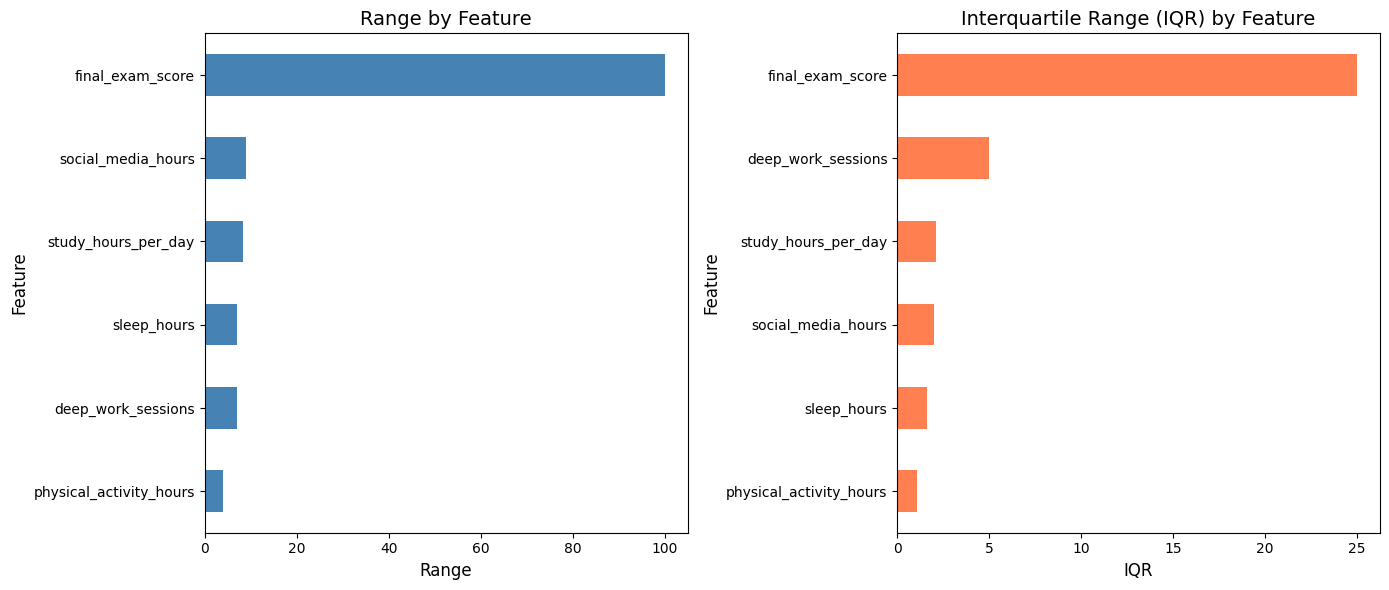

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Range
spread['Range'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Range by Feature', fontsize=14)
axes[0].set_xlabel('Range', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)

# IQR
spread['IQR'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Interquartile Range (IQR) by Feature', fontsize=14)
axes[1].set_xlabel('IQR', fontsize=12)
axes[1].set_ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.show()

**These two diagrams represent the measures of spread for selected features.**

**The Range chart shows that `final_exam_score` has the highest spread (100.0), indicating that student performance varies across the full spectrum of possible scores. `study_hours_per_day` (8.0), `deep_work_sessions` (7.0), and `sleep_hours` (7.0) show moderate ranges, while `social_media_hours` (9.0) and `physical_activity_hours` (4.0) have the lowest ranges, suggesting more consistent student behavior in these areas.**

**The IQR chart reveals that `final_exam_score` has the largest interquartile range (25.0), meaning that the middle 50% of students show considerable variability in their exam results. `deep_work_sessions` (5.0) and `social_media_hours` (2.0), `study_hours_per_day` (2.0), and `sleep_hours` (2.0) show moderate IQR values, while `physical_activity_hours` (1.0) has the smallest IQR, indicating that most students have similar levels of physical activity**

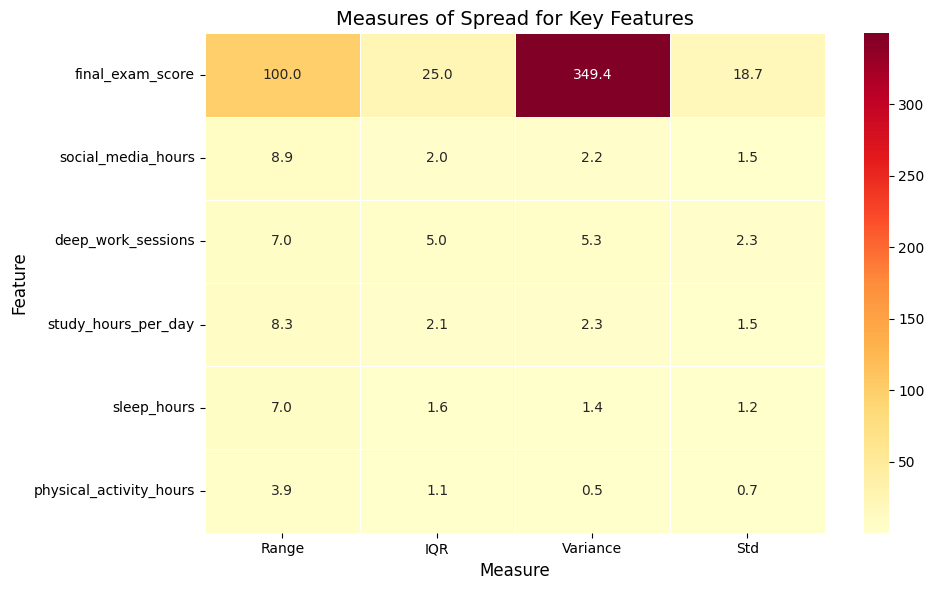

In [95]:
# Measure of spread heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(spread, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Measures of Spread for Key Features', fontsize=14)
plt.xlabel('Measure', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

**Heatmap data visualization is a powerful tool used to represent numerical data graphically, where values are depicted using colors. This method is particularly effective for identifying patterns, trends, and anomalies within large datasets [9].**

**The heatmap visualizes the measures of spread for the six key features. The color gradient ranges from light yellow (low values) to dark red (high values) [9]. The darkest red cells are concentrated in the `final_exam_score` row, particularly for Variance (349.0) and Range (100.0), indicating that this feature has the highest variability. In contrast, the lightest cells appear in the `physical_activity_hours` and `sleep_hours` rows, confirming that these features have the lowest spread. This pattern suggests that while academic performance varies greatly among students, their lifestyle habits are more consistent.**

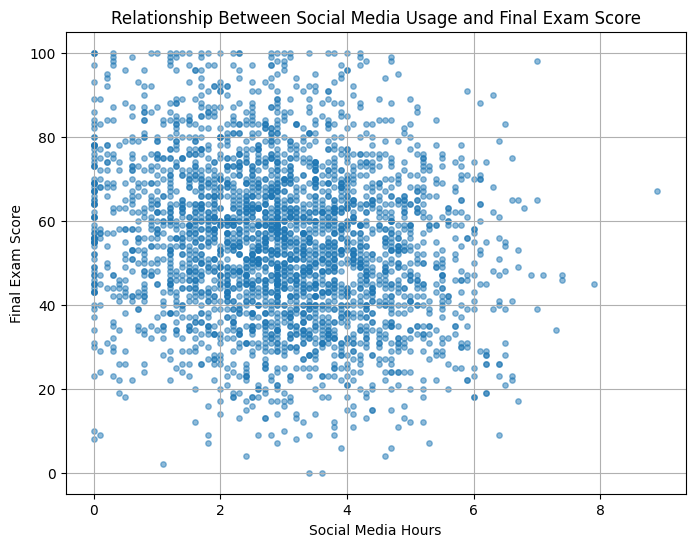

In [96]:
# Relationsip between two features: social media hours and final exam score
plt.figure(figsize=(8,6))

plt.scatter(df_copy['social_media_hours'], df_copy['final_exam_score'], alpha=0.5, s=15)

plt.xlabel('Social Media Hours')
plt.ylabel('Final Exam Score')
plt.title('Relationship Between Social Media Usage and Final Exam Score')

plt.grid()
plt.show()

**This scatter plot illustrates the relationship between social media usage and students’ final exam scores. The visualisation suggests a negative relationship between the two variables, where students with lower social media usage tend to achieve higher exam scores. Most of the observations with higher final scores appear to be concentrated at lower values of social media hours. However, the spread of the data indicates that social media usage alone is not sufficient to explain academic performance, and additional factors may influence student outcomes.**

#### 4.3. Type of distribution

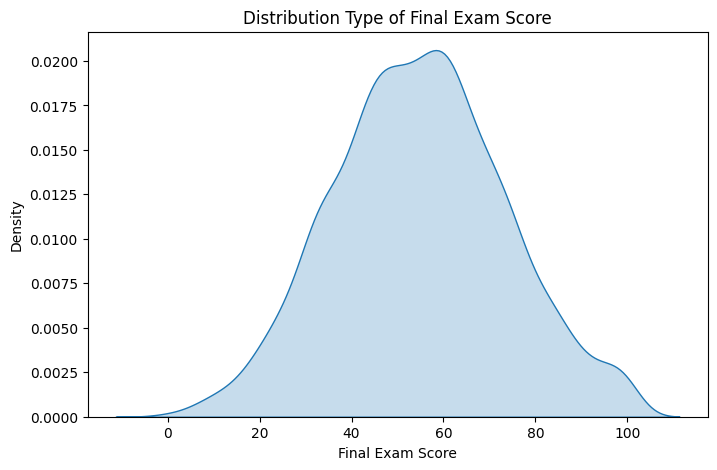

In [97]:
# The diagram of final_exam_score distribution
plt.figure(figsize=(8,5))

sns.kdeplot(df_copy['final_exam_score'], fill=True)
plt.title('Distribution Type of Final Exam Score')
plt.xlabel('Final Exam Score')
plt.ylabel('Density')
plt.show()

**The distribution type of the dataset target is approximately normally distributed with no significant skew.**

**As can be seen, the data follows a bell shape, with most values clustering around a central region. Indeed, the normal distribution frequently appears in nature and life in various forms. This is particularly favorable for linear regression, as the model performs well when the target variable is approximately normally distributed.**

## Q6. Machine Learning model

To build the regression model, the target variable (y) was selected as `final_exam_score`, representing student academic achievement measured on a continuous scale from 0 to 100. Since linear regression predicts numerical outcomes, this variable is appropriate for the selected modelling approach.

The input variables (X) include all remaining transformed features except `student_id` and `performance_category`. The `student_id` column was excluded because it acts only as an identifier and does not contain meaningful predictive information. The `performance_category` variable was also removed because it is derived from exam performance and could introduce target leakage into the model.

The selected features represent multiple dimensions of student behaviour and academic performance. Study-related variables such as `study_hours_per_day`, `deep_work_sessions`, and `revision_efficiency` provide information about learning effort and study consistency. Behavioural variables, including `social_media_hours`, `gaming_hours`, and `procrastination_index`, may negatively affect concentration and productivity. Well-being indicators such as `sleep_hours`, `stress_level`, and `physical_activity_hours` were included because physical and mental conditions can influence academic outcomes. Using a diverse set of features allows the model to capture a broader range of factors associated with student performance.

In [98]:
# Split data into features and labels
X, y = final_df.drop(columns=['student_id','final_exam_score', 'performance_category'], errors='ignore'), final_df['final_exam_score']

# Split X, y into train/test_X, _y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape X_train: {X_train.shape}; \nShape X_test: {X_test.shape}")

Shape X_train: (2400, 37); 
Shape X_test: (600, 37)


According to the division of the data using `test_size=0.2`, 20% of the data will be used for testing and the remaining 80% for training. The training subset was used to fit the model, while the testing subset was used to evaluate predictive performance on unseen data.

In [99]:
# Creating a model
model = LinearRegression()

model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


Linear Regression from Scikit-learn was selected because the target variable is continuous and several explanatory variables are expected to have approximately linear relationships with academic performance.

In [100]:
# Retrive feature importance for trained model
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})

feature_importance = feature_importance.sort_values(by='Coefficient', key=abs, ascending=False)
feature_importance.head(10)

,Feature,Coefficient
1,study_hours_per_day,33.001869
23,consistency_score,19.168486
5,social_media_hours,-18.406841
13,procrastination_index,-17.916998
12,focus_score,17.757482
21,revision_efficiency,13.245070
22,burnout_risk,-13.101885
11,motivation_level,12.933023
3,assignment_completion_rate,11.750443
14,sleep_hours,11.300456


**The table of feature coefficients identifies the key factors that most strongly influence students' academic performance. Among these, `study_hours_per_day` (coefficient: 33.00) and `consistency_score` (coefficient: 19.17) have the largest positive impact on the final exam score. This suggests that students who dedicate more time to studying and maintain consistent study habits tend to achieve significantly higher results.**

**In contrast, `social_media_hours` (coefficient: -18.41) and `procrastination_index` (coefficient: -17.92) show strong negative coefficients, indicating that higher social media usage and procrastination are associated with lower academic performance.**

**Other notable factors include `focus_score` (17.76), `revision_efficiency` (13.25), and `motivation_level` (12.93), all of which positively contribute to academic success. These results confirm that academic performance is influenced by a combination of study habits, behavioral patterns, and psychological factors.**

In [101]:
# Get prediction
y_pred = model.predict(X_test)

# Metrics for regression
metrics = pd.DataFrame({
    'MAE': [mean_absolute_error(y_test, y_pred)],
    'MSE': [mean_squared_error(y_test, y_pred)],
    'RMSE': [mean_squared_error(y_test, y_pred) ** 0.5],
    'R2': [r2_score(y_test, y_pred)]
}, index=["Metrics"])

metrics.round(2)

,MAE,MSE,RMSE,R2
Metrics,6.51,65.0,8.06,0.81


The linear regression model demonstrated good predictive performance on the testing dataset. The Mean Absolute Error (MAE) equals 6.51, meaning that the predicted exam score differs from the actual score by approximately 6–7 points on average. The Root Mean Squared Error (RMSE) is 8.06, indicating that larger prediction errors remain relatively limited.

The coefficient of determination (R²) achieved a value of 0.81, meaning that approximately 81% of the variation in student final exam scores can be explained by the selected input features. This suggests that the model fits the data well and captures most of the underlying relationships.

Since the evaluation metrics indicate strong predictive performance, no additional preprocessing was considered necessary at this stage. However, further improvements could be achieved through feature selection, residual analysis, or experimenting with alternative regression approaches.

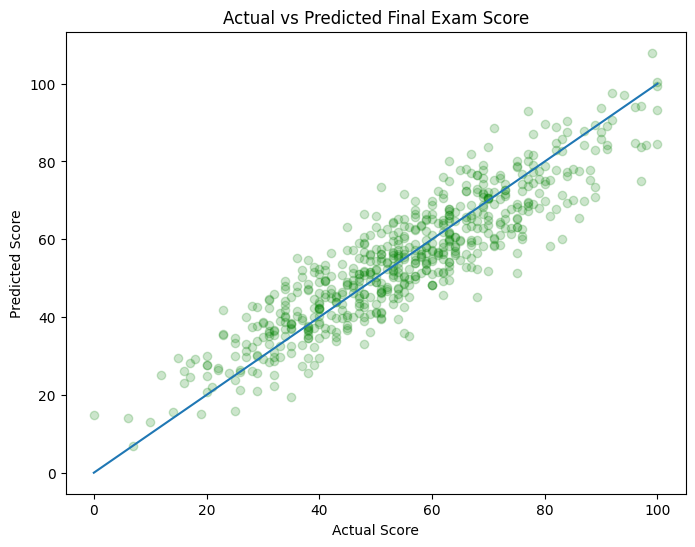

In [102]:
# The graph of actual and predicted scores
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='g', alpha=0.2)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Final Exam Score')
plt.show()

**As can be observed, most points lie close to the reference line, indicating that the model predictions closely follow the actual values.**

## Q7. Validation

Validation is an important stage of machine learning because it helps determine whether the model generalises well to unseen data rather than fitting only the training subset. A single train–test split may produce optimistic or unstable results depending on how observations are distributed. Therefore, cross-validation was applied to evaluate the stability and reliability of the regression model.

Cross-validation is a technique used to evaluate the performance of a machine learning model by splitting the dataset into multiple subsets. The model is repeatedly trained and tested on different portions of the data to obtain a more robust and reliable estimate of its predictive ability.

In [103]:
# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

# Results table
validation = pd.DataFrame({
    'Fold': range(1, 6),
    'R2 Score': cv_scores
})

print(validation)

# Summary statistics
print()
print(f"Mean R²: {cv_scores.mean():.3f}")
print(f"Std: {cv_scores.std():.3f}")

   Fold  R2 Score
0     1  0.802905
1     2  0.791693
2     3  0.826252
3     4  0.783192
4     5  0.816085

Mean R²: 0.804
Std: 0.016


Cross-validation was applied using 5 folds to evaluate the stability of the linear regression model. The results show a mean R² score of 0.804, indicating that the model consistently explains approximately 80% of the variance in the target variable across different subsets of the data.

The low standard deviation (0.016) suggests that the model performance is stable and does not significantly depend on the specific training-test split. This indicates good generalisation ability and confirms that the model is not overfitting.

## Q8. Feature Engineering

Despite the fact that the model produces good results, there is a need to reconsider the current features to evaluate and enhance its predictions.

Indeed, the analysis suggests that many of the features may be superfluous or less relevant for linear regression. The Pearson correlation coefficient is the most common way of measuring a linear correlation, which is particularly helpful for feature engineering. It describes the strength and direction of the linear relationship between two quantitative variables.

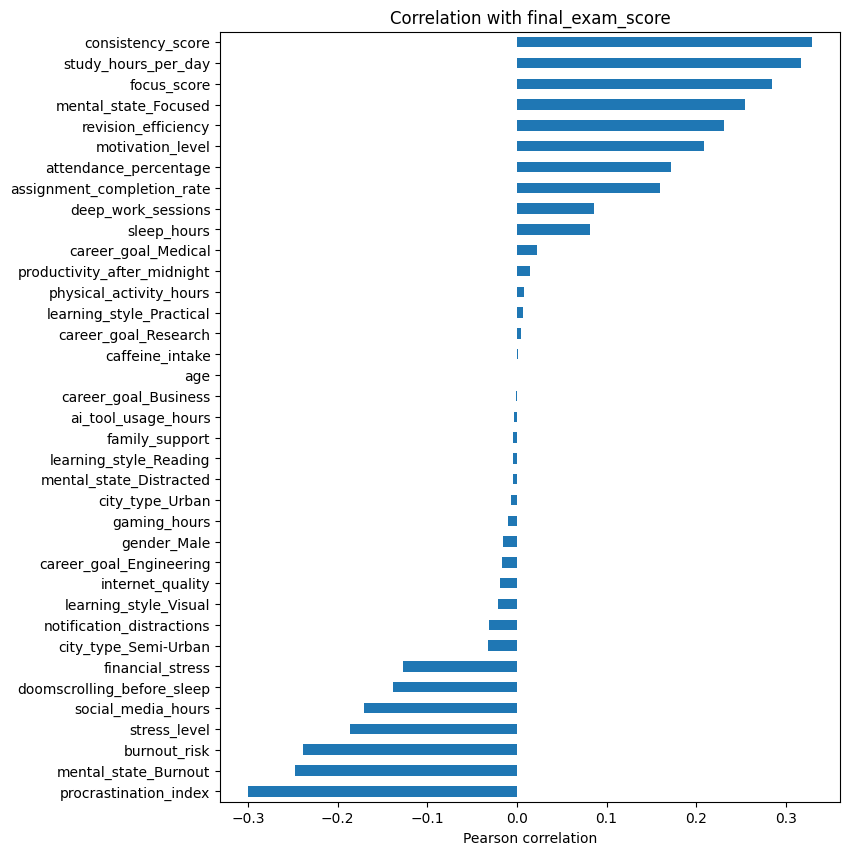

In [104]:
# The Pearson correlation
correlation = final_df.corr(numeric_only=True)['final_exam_score'].drop('final_exam_score').sort_values()

plt.figure(figsize=(8,10))
correlation.plot(kind='barh')
plt.title('Correlation with final_exam_score')
plt.xlabel('Pearson correlation')
plt.show()

**This diagram helps identify features that have weak linear relationships with the target variable and may be considered for removal during feature selection. The correlation analysis reveals that many features, such as `age`, `gender`, `city_type`, `caffeine_intake`, and `career_goal`, have very weak correlations with `final_exam_score`. These features could be considered for removal in future iterations to simplify the model and improve interpretability.** 

**To investigate whether domain-specific feature engineering could improve the predictive performance of the model, several composite features were created based on academic and behavioural characteristics.**

In [105]:
# Feature engineering:
final_df['healthy_lifestyle_index'] = (final_df['sleep_hours'] + final_df['physical_activity_hours']) / 2
final_df['digital_distraction_score'] = (final_df['social_media_hours'] + final_df['gaming_hours'] + final_df['doomscrolling_before_sleep']) / 3
final_df['study_efficiency_index'] = final_df['revision_efficiency'] * final_df['focus_score'] / (1 + final_df['procrastination_index'])
final_df['academic_effort_score'] = (final_df['study_hours_per_day'] + final_df['assignment_completion_rate'] + final_df['consistency_score']) / 3
final_df['mental_wellbeing_score'] = (final_df['sleep_hours'] + final_df['motivation_level'] - final_df['stress_level']) / 3

new_features = ['healthy_lifestyle_index', 'digital_distraction_score', 'study_efficiency_index', 'academic_effort_score', 'mental_wellbeing_score']

for feature in new_features:
    corr = final_df[feature].corr(final_df['final_exam_score'])
    print(f"{feature}: {corr:.2f}")

healthy_lifestyle_index: 0.06
digital_distraction_score: -0.18
study_efficiency_index: 0.39
academic_effort_score: 0.45
mental_wellbeing_score: 0.30


Several composite features were engineered to capture relationships that may not be represented by the original variables. The Pearson correlation coefficient was used to evaluate the strength of their relationship with `final_exam_score`.

The `academic_effort_score` showed the strongest positive correlation of approximately 0.45, indicating that students who dedicate more time to studying, complete assignments, and maintain consistent habits tend to achieve higher exam scores. The second most significant feature is the `study_efficiency_index`, which also demonstrated a strong positive correlation (0.39), suggesting that the quality of study sessions matters as much as quantity. Another positive effect was observed for the `mental_wellbeing_score`. This composite feature showed a moderate positive correlation of approximately 0.30, confirming that psychological factors influence academic performance.

However, there is another factor that negatively affects studying. The feature with a negative correlation of -0.18 is the `digital_distraction_score`. This discovery supports the hypothesis that excessive digital activity is associated with lower academic outcomes.

Interestingly, the `healthy_lifestyle_index` showed only a weak correlation of 0.06, suggesting that sleep and physical activity, when combined, do not capture the full complexity of health-related effects on academic performance.

In [106]:
# function for testing models
def evaluate_model(X, y, model_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {mse ** 0.5:.2f}")
    print(f"R²: {r2:.2f}")
    print(f"Number of features: {X.shape[1]}")
    print()

To evaluate the impact of feature engineering, four regression models were compared:

- Model 1 uses all available features after preprocessing.
- Model 2 removes variables with very weak correlation to the target variable.
- Model 3 extends the original dataset by adding engineered composite features.
- Model 4 applies automatic feature selection using SelectKBest to retain the 20 most informative predictors.

In [107]:
y = final_df['final_exam_score']

# Model 1: original features
original_features = [
    col for col in final_df.columns
    if col not in [
        'final_exam_score',
        'performance_category',
        'healthy_lifestyle_index',
        'digital_distraction_score',
        'study_efficiency_index',
        'academic_effort_score',
        'mental_wellbeing_score'
    ]
]

X_all = final_df[original_features]

# Model 2: remove weakly correlated features
low_corr_features = [
    'age',
    'gender_Male',
    'city_type_Urban',
    'city_type_Semi-Urban',
    'caffeine_intake',
    'gaming_hours',
    'internet_quality',
    'learning_style_Reading',
    'learning_style_Visual',
    'family_support',
    'career_goal_Business',
    'career_goal_Engineering',
    'career_goal_Medical',
    'career_goal_Research'
]

important_features = [
    col for col in original_features
    if col not in low_corr_features
]

X_selected = final_df[important_features]

# Model 3: original + engineered features
X_engineered = final_df.drop(
    columns=['final_exam_score', 'performance_category']
)

# Model 4: automatic feature selection
selector = SelectKBest(score_func=f_regression, k=20)

X_new = selector.fit_transform(X_engineered, y)

In [108]:
evaluate_model(X_all, y, "Model 1. Original features")
evaluate_model(X_selected, y, "Model 2. Important features")
evaluate_model(X_engineered, y, "Model 3. Engineered features")
evaluate_model(X_new, y, "Model 4. Selected features")

print("\nNumber of features:")
print(f"Model 1: {X_all.shape[1]}")
print(f"Model 2: {X_selected.shape[1]}")
print(f"Model 3: {X_engineered.shape[1]}")
print(f"Model 4: {X_new.shape[1]}")

Model 1. Original features:
MSE: 65.00
RMSE: 8.06
R²: 0.81
Number of features: 37

Model 2. Important features:
MSE: 64.94
RMSE: 8.06
R²: 0.81
Number of features: 23

Model 3. Engineered features:
MSE: 65.07
RMSE: 8.07
R²: 0.81
Number of features: 42

Model 4. Selected features:
MSE: 64.32
RMSE: 8.02
R²: 0.81
Number of features: 20


Number of features:
Model 1: 37
Model 2: 23
Model 3: 42
Model 4: 20


The comparison demonstrates that adding engineered composite features did not significantly improve the predictive performance of the linear regression model. This suggests that the original variables already contained most of the useful information, and the engineered features introduced little additional predictive value.

In contrast, reducing the number of predictors proved to be more beneficial. Removing weakly correlated variables slightly improved the model while reducing its complexity, and the automatic feature selection approach (SelectKBest) achieved the lowest MSE using only 20 features. This indicates that selecting the most informative predictors is more effective for this dataset than creating additional composite variables.

## Conslusion

To conclude, the project successfully demonstrates the application of linear regression to predict student academic performance using a combination of behavioural, psychological, and lifestyle factors. The findings confirm that variables such as `study_hours_per_day`, `consistency_score`, and `motivation_level` are strong positive predictors, while `social_media_hours` and `procrastination_index` negatively impact performance.

To evaluate the impact of feature engineering and selection, four regression models were compared. Model 1 uses all original features after preprocessing. Model 2 removes variables with very weak correlation to the target variable. Model 3 extends the original dataset by adding engineered composite features. Model 4 applies automatic feature selection using SelectKBest to retain the 20 most informative predictors. The comparision demostrates that Model 4, which applied automatic feature selection, achieved the lowest MSE (64.32) and RMSE (8.02) using only 20 features. This indicates that selecting the most informative predictors is more effective for this dataset than creating additional composite variables.

The performance of the linear regression model was evaluated using three primary metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Among these, RMSE was selected as the primary evaluation metric because it is measured in the same units as the target variable (final_exam_score), making it more interpretable in the context of student performance. MSE provides a measure of the average squared difference between predicted and actual scores, while R² indicates the proportion of variance in the target variable explained by the model.

The solution is transferable to other domain-specific areas that involve predicting continuous outcomes based on behavioural and demographic factors. For example, similar approaches could be applied in healthcare to predict patient recovery times, in marketing to forecast customer lifetime value, or in human resources to estimate employee performance. However, the model's effectiveness depends on the availability of relevant features and the assumption of linear relationships, which may not hold in all domains.

# References
[1]  AI Explorer. (2026). Student Academic Performance Prediction [Dataset]. Kaggle. 
https://www.kaggle.com/datasets/aiexplorer77/academic-performance-prediction 

[2] Bum, S., Iorliam, I. B., Okube, E. O., & Iorliam, A. (2019). Prediction of Student’s Academic Performance Using Linear Regression. NIGERIAN ANNALS OF PURE AND APPLIED SCIENCES, 1, 259-264.

[3] EducationData.org. (2025, July 7). College Dropout Rate [2025]: by Year + Demographics. https://educationdata.org/college-dropout-rates

[4] Wilber, J. (2022, September). Linear Regression. MLU-Explain. https://mlu-explain.github.io/linear-regression/

[5] PythonRSAS. (2020, January 8). Linear Regression II Categorical Data Preparation. https://pythonrsas.github.io/4-Linear-Regression-II-Categorical-Data-Preparation/

[6] Dey, R. (2023, December 8). Normal Distribution and its Significance. Medium. https://medium.com/@roshmitadey/normal-distribution-and-its-significance-10fea108588c

[7] GeeksforGeeks. (2021, February 21). Data Pre-Processing with Sklearn using Standard and Minmax scaler. https://www.geeksforgeeks.org/machine-learning/data-pre-processing-wit-sklearn-using-standard-and-minmax-scaler/

[8] GeeksforGeeks. (2021, February 19). Measure of Central Tendency in Statistics. https://www.geeksforgeeks.org/maths/measures-of-central-tendency/

[9] GeeksforGeeks. (2024, June 12). What is Heatmap Data Visualization and How to Use It? https://www.geeksforgeeks.org/data-visualization/what-is-heatmap-data-visualization-and-how-to-use-it/